<h1> Mini Project Data Visualisasi & EDA </h1>
<H2>ANALISIS BIGMART SALES DATA</H2>

<h3>A. Import Library</h3>

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<b>Penjelasan</b>
<p>
    Library pandas digunakan untuk manipulasi data, pengolahan DataFrame, atau analisis data terstruktur. Library numpy untuk komputasi numerik, operasi matriks/vektor, dan array multidimensi. Library matplotlib dan seabron digunakan untuk visualisasi data atau pembuatan grafik statistik.
</p> 

<h3>B. Import File Data</h3>

<p>Import file BigMart Sales Data.csv ke dalam DataFrame</p> 

In [117]:
df = pd.read_csv('BigMart Sales Data.csv')
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


<b>Hasil Pengamatan</b>
<p>
    File Bigmart Data Sales.csv di import ke dalam dataframe diwakilkan variabel df untuk memudahkan dalam proses analisis untuk memenuhi tujuan mendapatkan insight dari file ini. dataframe berisi 8523 baris dan 12 kolom, berikut pengertian setiap kolom:
    <br>
    <br>Item_Identifier: (Primary Key) Kode ID unik untuk setiap produk (contoh: FDA15).
    <br>Item_Weight: Berat fisik dari produk.
    <br>Item_Fat_Content: Status kandungan lemak pada produk (misal: Low Fat, Regular).
    <br>Item_Visibility: Persentase area rak toko (Outlet) yang dialokasikan untuk memajang suatu produk (Item)
    <br>Item_Type: Kategori jenis produk (misal: Dairy, Soft Drinks, Meat).
    <br>Item_MRP: Maximum Retail Price (Harga Eceran Tertinggi). Pada dataset ini, harganya bisa sedikit bervariasi bergantung pada toko yang menjualnya.
    <br>Outlet_Identifier: (Primary Key) Kode ID unik untuk setiap toko (contoh: OUT049, OUT027).
    <br>Outlet_Establishment_Year: Tahun di mana toko tersebut pertama kali dibuka.
    <br>Outlet_Size: Ukuran luas fisik bangunan toko (Small, Medium, High).
    <br>Outlet_Location_Type: Tingkatan kota letak toko beroperasi (Tier 1, Tier 2, Tier 3).
    <br>Outlet_Type: Model bisnis dari toko tersebut (Grocery Store, Supermarket Type 1, dll).
    <br>Item_Outlet_Sales: Total pendapatan dari penjualan suatu produk di suatu toko. Ini adalah kolom target utama (hasil akhir).
    <br>
    <br>
    berdasarkan dari nama kolom, dataframe ini dapat dibagi dua menjadi tabel produk (Item_Identifier, Item_Weight, Item_Fat_Content, Item_Visibility, Item_Type, Item_MRP) dan tabel outlet (Outlet_Identifier, Outlet_Establishment_Year, Outlet_Size, Outlet_Location_Type, Outlet_Type, dan Item_Outlet_Sales)
</p>


<h3>C. Data Exploration</h3>

<b>Eksplorasi Data untuk Memeriksa Konsistensi Data</b>

<h4>a. cek dataframe</h4>

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


<b>Hasil pengamatan dari df.info</b>
<p>
    Dataframe BigMart Sales Data memiliki 12 kolom dan 8523 baris
    <br>Kolom Item_Identifier, Item_Fat_Content, Item_Type, Outlet_Identifier, Outlet_Size, Outlet_Location_Type, dan Outlet Type bertipe data jenis kategorikal
    <br>Kolom Item_Weight, Item_Visibility, Item_MRP,Outlet_Establishment_Year, dan Item_Outlet_Sales bertipe data nominal
    <br>Kolom Item_Weight dan Outlet_Size memiliki jumlah data yang lebih sedikit dibandingkan kolom lainnya (terdapat missing value)
    <br>Kolom Outlet_Establishment_Year bertipe data integer belum bertipe datetime
</p>

In [119]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


<b>Hasil pengamatan df.describe</b>
<p>
    Item_Weight: Memiliki jumlah data (count) sebanyak 7.060 baris, yang menunjukkan adanya selisih dari total 8.523 baris data (terdapat missing value).
    <br>Item_Visibility: Nilai minimumnya bernilai 0.00, diperlukan eksplorasi lebih dalam untuk kolom ini.
    <br>Item_MRP: Harga rata-rata (mean) produk berada di angka 140.99, dengan harga terendah sebesar 31.29 dan tertinggi 266.89.
    <br>Outlet_Establishment_Year: Tahun pendirian outlet dalam data berkisar dari tahun 1985 hingga tahun 2009.
    <br>Item_Outlet_Sales: Angka penjualan rata-rata (mean) tercatat di 2181.29, dengan nilai penjualan maksimum mencapai 13086.96.
    <br>nilai minimal pada item_visibility bernilai 0,0 perlu diperiksa apakah dibutuhkan imputasi atau tidak karena barang yg tidak terlihat di rak masih bisa terjual
</p>

<h4>b. Eksplorasi lebih dalam kolom Item_Visibility</h4>

<h5>1. Validasi dengan domain knowledge</h5>

In [120]:
missing_rak = df[df['Item_Visibility'] == 0]
missing_rak

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.200,Regular,0.0,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.0,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.0,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
10,FDY07,11.800,Low Fat,0.0,Fruits and Vegetables,45.5402,OUT049,1999,Medium,Tier 1,Supermarket Type1,1516.0266
32,FDP33,18.700,Low Fat,0.0,Snack Foods,256.6672,OUT018,2009,Medium,Tier 3,Supermarket Type2,3068.0064
...,...,...,...,...,...,...,...,...,...,...,...,...
8480,FDQ58,NaN,Low Fat,0.0,Snack Foods,154.5340,OUT019,1985,Small,Tier 1,Grocery Store,459.4020
8484,DRJ49,6.865,Low Fat,0.0,Soft Drinks,129.9652,OUT013,1987,High,Tier 3,Supermarket Type1,2324.9736
8486,FDR20,20.000,Regular,0.0,Fruits and Vegetables,46.4744,OUT010,1998,NaN,Tier 3,Grocery Store,45.2744
8494,NCI54,15.200,Low Fat,0.0,Household,110.4912,OUT017,2007,NaN,Tier 2,Supermarket Type1,1637.8680


In [121]:
#cek jumlah data dengan visibilitas 0
missing_rak.shape[0]

526

<b>Hasil Pengamatan</b>
<p>
    Kolom_Visibility yang bernilai 0 berjumlah 526 baris dan memiliki total pendapatan dari penjualan produk tertentu. Dalam dunia retail hal ini sangat mustahil karena produk yang tidak dipajang tidak mungkin terjual oleh konsumen. dibutuhkan eksplorasi lebih lanjut untuk mengatasi kolom Item_Visibility bernilai 0
</p>

<h5>2. melihat persebaran data visibilitas 0</h5>

In [122]:
# membuat variabel untuk menghitung jumlah data tiap outlet 
jml_outlet_tipe = missing_rak['Outlet_Identifier'].value_counts().reset_index()
jml_outlet_tipe

,Outlet_Identifier,count
0,OUT018,65
1,OUT046,61
2,OUT027,60
3,OUT013,59
4,OUT045,58
5,OUT017,57
6,OUT035,54
7,OUT049,53
8,OUT019,30
9,OUT010,29


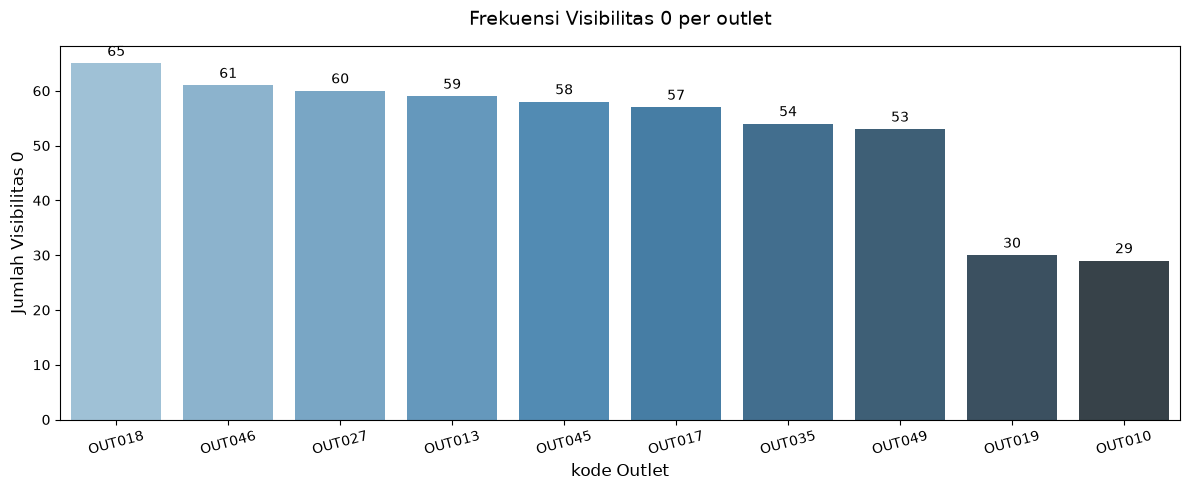

In [123]:
# melakukan visualisasi terhadap variabel jml_outlet0
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=jml_outlet_tipe, x='Outlet_Identifier', y='count', hue='Outlet_Identifier', legend=False, palette='Blues_d')
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.title('Frekuensi Visibilitas 0 per outlet', fontsize=14, pad=15)
plt.xlabel('kode Outlet', fontsize=12)
plt.ylabel('Jumlah Visibilitas 0', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<h5>3.Keputusan visibilitas 0</h5>

<p>
    Berdasarkan pada grafik diatas produk dengan visibilitas 0 dan memiliki pendapatan penjualan tersebar diseluruh outlet, dapat disimpulkan sebagai kesalahan input. Produk dengan visibilitas 0 akan dikosongkan (bukan angka 0) yang selanjutnya akan diganti dengan nilai yang sesuai untuk membuat data konsisten
</p>

<h5>4.Imputasi</h5>

In [124]:
# membuat data salinan sementara sebelum cleaning
df_semi=df.copy()

In [125]:
df_semi['Item_Visibility'] = df_semi['Item_Visibility'].replace(0, np.nan)
# cek nilai yang kosong
df_semi['Item_Visibility'].isna().sum()

np.int64(526)

In [126]:
df['Item_Visibility'].isna().sum()

np.int64(0)

<b>Hasil pengamatan</b>
<p>
    pada salinan dataframe kolom Item_visibility memiliki missing value sebanyak 526 baris. akan diperlukan perhitungan persentase untuk keputusan selanjutnya
</p>

<h4>c. Cek Data Hilang</h4>

In [127]:
#cek persentase missing value
df_miss = pd.DataFrame({
    'data_hilang' : df_clean.isna().sum(),
    'Percentage'  : (df_clean.isna().mean()*100).round(2)
})
df_miss = df_miss[df_miss['data_hilang'] > 0]
df_miss

,data_hilang,Percentage
Item_Weight,1463,17.17
Item_Visibility,526,6.17
Outlet_Size,2410,28.28


<b>Hasil pengamatan dari df_miss</b>
<p>
    kolom Item_Weight memiliki persentase 17,17% diperlukan pengujian lebih lanjut
    <br> kolom Item_Visibility memiliki persentase 6,17% diperlukan pengujian lebih lanjut
    <br>kolom Outlet_Size memiliki persetase 28.28% diperlukan pengujian lebih lanjut
</p>

<h4>d. Cek duplikasi data</h4>

In [128]:
#cek duplikat setiap baris
duplikat_jml = df_clean.duplicated().sum()
duplikat_persen = (duplikat_jml / len(df)) * 100
print(f"Jumlah baris duplikat: {duplikat_jml} ({duplikat_persen:.2f}%)")

Jumlah baris duplikat: 0 (0.00%)


<b>Hasil pengamatan dari cek duplikat</b>
<p>
    tidak ada data yang duplikat 
</p>

<h4>e. Cek kolom utama</h4>

In [129]:
#checking kolom yang mewakili nilai setiap baris
for col in df.columns:
    jumlah_unik = df_clean[col].nunique()
    print(f"Kolom {col}: {jumlah_unik} nilai unik")

Kolom Item_Identifier: 1559 nilai unik
Kolom Item_Weight: 415 nilai unik
Kolom Item_Fat_Content: 5 nilai unik
Kolom Item_Visibility: 7879 nilai unik
Kolom Item_Type: 16 nilai unik
Kolom Item_MRP: 5938 nilai unik
Kolom Outlet_Identifier: 10 nilai unik
Kolom Outlet_Establishment_Year: 9 nilai unik
Kolom Outlet_Size: 3 nilai unik
Kolom Outlet_Location_Type: 3 nilai unik
Kolom Outlet_Type: 4 nilai unik
Kolom Item_Outlet_Sales: 3493 nilai unik


<b>Hasil eksplorasi dari checking nilai unik setiap kolom</b>
<p>
    Tidak ditemukan kolom yang unik untuk mewakili setiap baris
</p>

<h4>f. Cek konsistensi data</h4>

In [130]:
#checking nilai kolom yang unik
cat_cols = df_clean.select_dtypes(include=['object', 'string', 'category', 'bool'])

df_ceksdf = pd.DataFrame([{
    'column': col,
    'unique_values': cat_cols[col].dropna().unique().tolist(),
    'n_unique': cat_cols[col].nunique(dropna=True)
} for col in cat_cols.columns])

pd.set_option('display.max_colwidth', None)
df_ceksdf

,column,unique_values,n_unique
0,Item_Identifier,"[FDA15, DRC01, FDN15, FDX07, NCD19, FDP36, FDO10, FDP10, FDH17, FDU28, FDY07, FDA03, FDX32, FDS46, FDF32, FDP49, NCB42, DRI11, FDU02, FDN22, FDW12, NCB30, FDC37, FDR28, NCD06, FDV10, DRJ59, FDE51, FDC14, FDV38, NCS17, FDP33, FDO23, DRH01, NCX29, FDV20, DRZ11, FDX10, FDB34, FDK43, FDA46, FDC02, FDL50, FDM39, NCP05, FDV49, FDL12, FDS02, NCL17, FDM40, FDR13, FDA43, NCP18, FDK21, NCX54, DRK35, FDY21, FDI26, FDM20, FDV27, FDF09, FDY40, FDY45, FDC46, FDH19, FDZ03, DRH37, NCI17, FDJ58, FDH35, FDG02, NCZ18, FDC29, FDQ10, FDN48, FDL04, FDV25, FDD58, FDN04, FDV45, NCL18, FDR12, FDG20, FDZ55, FDQ49, FDN33, FDN27, FDW20, DRG27, DRI25, FDA44, NCR17, FDU04, FDF41, FDB56, FDT28, FDD10, FDW57, DRB48, FDP09, ...]",1559
1,Item_Fat_Content,"[Low Fat, Regular, low fat, LF, reg]",5
2,Item_Type,"[Dairy, Soft Drinks, Meat, Fruits and Vegetables, Household, Baking Goods, Snack Foods, Frozen Foods, Breakfast, Health and Hygiene, Hard Drinks, Canned, Breads, Starchy Foods, Others, Seafood]",16
3,Outlet_Identifier,"[OUT049, OUT018, OUT010, OUT013, OUT027, OUT045, OUT017, OUT046, OUT035, OUT019]",10
4,Outlet_Size,"[Medium, High, Small]",3
5,Outlet_Location_Type,"[Tier 1, Tier 3, Tier 2]",3
6,Outlet_Type,"[Supermarket Type1, Supermarket Type2, Grocery Store, Supermarket Type3]",4


In [131]:
# Export hasil nilai unik per kolom untuk dianalisa oleh AI memeriksa nilai yang tidak konsisten
df_ceksdf.to_csv('nilai unique.csv', index=False)

<b>Hasil Analisa AI</b>
<p>
    terdapat inkonsistensi nilai pada kolom Item_Fat_Content dan nilai pada kolom lain sudah konsisten (tidak redundan) 
</p>

<h3>D. Data Cleaning</h3>

<h4>1. Menggunakan salinan dataframe</h4>

In [132]:
# menggunakan salinan dataframe untuk proses cleaning (yang sudah nilai visibilitas 0 dikosongkan nilainya)
df_clean=df_semi.copy()

<h4>2. Tindakan Inkonsistensi Data</h4>

In [133]:
# cek inkonsistensi nilai pada kolom Item_Fat_Content
df['Item_Fat_Content'].unique()

<ArrowStringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

<b>Keputusan Inkonsistensi data</b>
<p>
    dilakukan penyeragaman nilai Low Fat, low fat,LF menjadi Low Fat begitu juga untuk Regular,reg menjadi Regular
</p>

In [134]:
# aksi untuk menyeragamkan inkonsistensi data Item_Fat_Content
df_clean['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})
df_clean['Item_Fat_Content'].unique()

<ArrowStringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str

<h4>3. Tindakan Missing Values</h4>

<h5>a. Tindakan Missing Values: Item_Weight</h5>

In [135]:
# Cek konsistensi berat pada kolom Item_Weight
weight_check = df_clean.groupby('Item_Identifier')['Item_Weight'].nunique()
print(f"Jumlah produk dengan variasi berat > 1: {(weight_check > 1).sum()}")

#menampilkan hasil data dengan Item_Identifier menghasilkan berat yang sama 
sample_id = df_clean[df_clean['Item_Weight'].isna()]['Item_Identifier'].iloc[2]
print(f"\nContoh perbandingan untuk Item_Identifier '{sample_id}':")

df_clean[df_clean['Item_Identifier'] == sample_id][['Item_Identifier', 'Item_Weight', 'Outlet_Identifier']]

Jumlah produk dengan variasi berat > 1: 0

Contoh perbandingan untuk Item_Identifier 'FDW12':


,Item_Identifier,Item_Weight,Outlet_Identifier
21,FDW12,NaN,OUT027
1788,FDW12,8.315,OUT010
2973,FDW12,8.315,OUT049
5319,FDW12,8.315,OUT013
6285,FDW12,8.315,OUT046
7004,FDW12,8.315,OUT045
7259,FDW12,8.315,OUT017


<b>Tindakan Missing Values pada Item_Weight</b>
<p>
    berdasarkan pengamatan dengan produk yang sama menggunakan kolom Item_Identifier nilai berat produk sama semuanya maka akan dilakukan Imputasi pada nilai Item_Weight yang kosong dengan menyesuaikan dengan Item_Identifier
</p>

In [136]:
# Aksi imputasi Item_Weight menggunakan nilai rata-rata dari Item_Identifier yang sama
df_clean['Item_Weight'] = df_clean.groupby('Item_Identifier')['Item_Weight'].transform(lambda x: x.fillna(x.mean()))

# Cek kembali jumlah missing value pada kolom Item_Weight setelah diimputasi
print("Sisa missing value pada Item_Weight:", df_clean['Item_Weight'].isna().sum())

Sisa missing value pada Item_Weight: 4


In [137]:
df_clean[df_clean['Item_Weight'].isna()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9198,OUT027,1985,Medium,Tier 3,Supermarket Type3,1569.9564
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0440,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.2280
4187,FDE52,NaN,Regular,0.029742,Dairy,88.9514,OUT027,1985,Medium,Tier 3,Supermarket Type3,3453.5046
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2098,OUT019,1985,Small,Tier 1,Grocery Store,120.5098


<b>Tindakan Lanjutan Missing Values pada Item_Weight</b>
<p>
    Setelah dilakukan Imputasi menyisakan 4 nilai yang masih kosong dikarenakan produk ini satu-satunya dan tidak ada pembanding, keputusan yang diambil adalah dilakukan Imputasi dengan nilai rata-rata berat dari kolom Item_Weight untuk mempertahankan nilai dari 'Item_Outlet_Sales'
</p>

In [153]:
#Imputasi 4 nilai yang kosong dengan rata-rata kolom Item_Weight
df_clean['Item_Weight'] = df_clean['Item_Weight'].fillna(df_clean['Item_Weight'].mean())

# Cek kembali jumlah missing value pada kolom Item_Weight setelah diimputasi
print("Sisa missing value pada Item_Weight:", df_clean['Item_Weight'].isna().sum())

Sisa missing value pada Item_Weight: 0


<h5>b.Tindakan Missing Values pada Outlet_Size </h5>

<p>
    karena tipe sebuah outlet mempengaruhi sebuah ukuran outlet maka akan diuji hubungan antar kolom Outlet_Size dengan kolom Outlet_Type
</p>

In [158]:
#Uji hubungan antar 2 kolom
pd.crosstab(df_clean['Outlet_Type'], df_clean['Outlet_Size'], dropna=False)

Outlet_Size,High,Medium,Small,NaN
Outlet_Type,,,,
Grocery Store,0,0,528,555
Supermarket Type1,932,930,1860,1855
Supermarket Type2,0,928,0,0
Supermarket Type3,0,935,0,0


<b>Hasil Pengamatan Antar 2 kolom</b>
<p>
    terdapat data yang hilang pada data bertipe Supermarket Type 1 dan Grocery. Data hilang yang bertipe Grocery terkonsentrasi dalam ukuran small, data Supermarket Type1 tersebar di setiap ukuran dibutuhkan uji lebih lanjut dengan kolom lain yang berhubungan dengan Outlet_Type yang bernilai Supermarket Type1 dengan Outlet_location Size
</p>

In [157]:
# uji lebih lanjut untuk nilai yang hilang dengan tipe Supermarket Type1 dengan kolom Outlet_Location_Type
sup1_df = df_clean[df_clean['Outlet_Type'] == 'Supermarket Type1']

# Crosstab antara Outlet_Location_Type dan Outlet_Size= Supermarket Type1
pd.crosstab(sup1_df['Outlet_Location_Type'], sup1_df['Outlet_Size'], dropna=False)

Outlet_Size,High,Medium,Small,NaN
Outlet_Location_Type,,,,
Tier 1,0,930,930,0
Tier 2,0,0,930,1855
Tier 3,932,0,0,0


<b>Hasil pengamatan Tabel</b>
<p>
    terlihat dari tabel nilai kosong berada pada Tier 2 dan jumlah Hgh dan Medium sudah sama dengan tabel yang dilakukan uji pertama kali sehingga nilai kosong yang bertipe Supermarket Type1 di imputasi dengan ukuran small, jadi semua data Outlet_Size yang kosong akan di isi dengan ukuran small 
</p>

In [160]:
# Imputasi nilai yang kosong pada Outlet_Size
df_clean['Outlet_Size'] = df_clean['Outlet_Size'].fillna('Small')

#cek apakah data yang di imputasi terisi dengan benar
pd.crosstab(df_clean['Outlet_Type'], df_clean['Outlet_Size'], dropna=False)

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,1083
Supermarket Type1,932,930,3715
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


<h5>c.Tindakan Missing Values pada Item_Visibility </h5>

<b>Keputusan Imputasi</b>
<p>
    nilai yang kosong akan diisi dengan nilai tengah dari kolom Item_Visibility berdasarkan produknya 
</p>

In [142]:
df_clean['Item_Visibility'] = df_clean['Item_Visibility'].fillna(
    df_clean.groupby('Item_Identifier')['Item_Visibility'].transform('median')
)

# Cek mapakah masih ada missing
print("Sisa missing value pada Item_Visibility:", df_clean['Item_Visibility'].isna().sum())

Sisa missing value pada Item_Visibility: 0


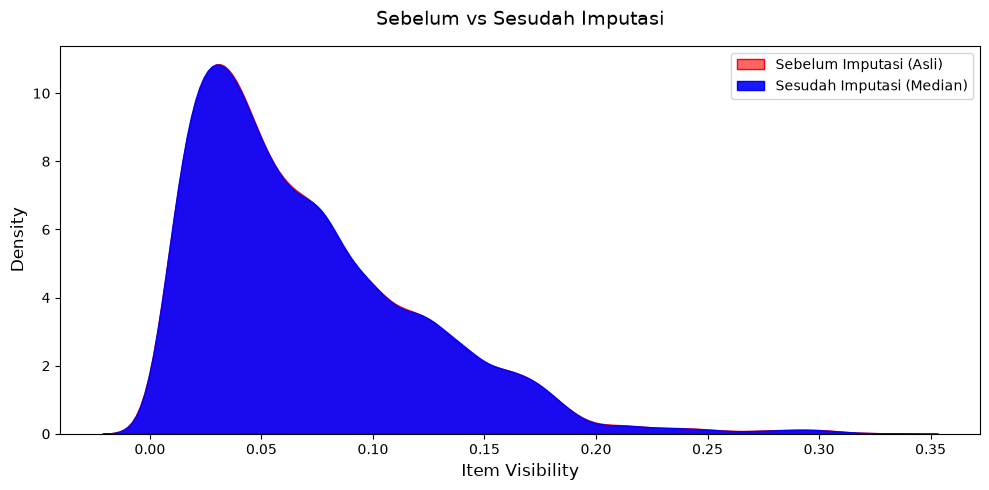

In [146]:
plt.figure(figsize=(10, 5))

# 1. Plot data sebelum imputasi
sns.kdeplot(
    data=df['Item_Visibility'].replace(0, float('nan')), 
    label='Sebelum Imputasi (Asli)', 
    color='red', 
    fill=True, 
    alpha=0.6
)

# 2. Plot data sesudah imputasi
sns.kdeplot(
    data=df_clean['Item_Visibility'], 
    label='Sesudah Imputasi (Median)', 
    color='blue', 
    fill=True, 
    alpha=0.9
)

plt.title('Sebelum vs Sesudah Imputasi', fontsize=14, pad=15)
plt.xlabel('Item Visibility', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

<b>Hasil pengamatan</b>
<p>
    hasil dari visualisasi hampir menyerupai sehingga tidak mempengaruhi analisis kedepannya
</p>

<h4>4. Mengidentifikasi Outlier dan Menangani Outlier</h4>

In [147]:
'''cek Outlier dengan IQR
'''
# Cek outlier untuk kolom Item_Outlet_Sales
Q1 = df_clean['Item_Outlet_Sales'].quantile(0.25)
Q3 = df_clean['Item_Outlet_Sales'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - (1.5 * IQR)
batas_atas = Q3 + (1.5 * IQR)

print(f"Batas Bawah: {batas_bawah}")
print(f"Batas Atas: {batas_atas}")

outlier_bawah = df_clean[df_clean['Item_Outlet_Sales'] < batas_bawah]
outlier_atas = df_clean[df_clean['Item_Outlet_Sales'] > batas_atas]
print(f"Jumlah baris di bawah batas normal: {len(outlier_bawah)} baris")
print(f"Jumlah baris data dengan penjualan di atas batas normal (outlier): {len(outlier_atas)} baris")

Batas Bawah: -2566.3261
Batas Atas: 6501.8699
Jumlah baris di bawah batas normal: 0 baris
Jumlah baris data dengan penjualan di atas batas normal (outlier): 186 baris


In [149]:
# Cek outlier untuk kolom Item_MRP
Q1_mrp = df_clean['Item_MRP'].quantile(0.25)
Q3_mrp = df_clean['Item_MRP'].quantile(0.75)
IQR_mrp = Q3_mrp - Q1_mrp

batas_atas_mrp = Q3_mrp + (1.5 * IQR_mrp)
batas_bawah_mrp = Q1_mrp - (1.5 * IQR_mrp)

print(f"Batas Bawah: {batas_bawah}")
print(f"Batas Atas: {batas_atas}")
outlier_bawah_mrp = df_clean[(df_clean['Item_MRP'] < batas_bawah_mrp)]
outlier_atas_mrp = df_clean[(df_clean['Item_MRP'] > batas_atas_mrp)]
print(f"Jumlah outlier pada Item_MRP: {len(outlier_bawah_mrp)} baris")
print(f"Jumlah outlier pada Item_MRP: {len(outlier_atas_mrp)} baris")

Batas Bawah: -2566.3261
Batas Atas: 6501.8699
Jumlah outlier pada Item_MRP: 0 baris
Jumlah outlier pada Item_MRP: 0 baris


In [150]:
# Cek outlier untuk kolom Item_Visibility
Q1_vis = df_clean['Item_Visibility'].quantile(0.25)
Q3_vis = df_clean['Item_Visibility'].quantile(0.75)
IQR_vis = Q3_vis - Q1_vis
batas_atas_vis = Q3_vis + (1.5 * IQR_vis)

print(f"Batas Atas Item_Visibility: {batas_atas_vis}")
outlier_visibilitas_tinggi = df_clean[df_clean['Item_Visibility'] > batas_atas_vis]
print(f"Jumlah baris data dengan Item_Visibility di atas batas normal: {len(outlier_visibilitas_tinggi)} baris")

Batas Atas Item_Visibility: 0.1982675565
Jumlah baris data dengan Item_Visibility di atas batas normal: 142 baris


<b>Hasil Pengamatan</b>
<p>
    Terdapat Outliers pada kolom Item_Outlet_Sales sejumlah 186 baris tapi dibiarkan karena data tersebut menunjukkan total penjualan yang tinggi
    <br>Terdapat Outliers pada kolom Item_Visibility sejumlah 142 baris tapi dibiarkan karena data tersebut menunjukkan barang yang dominan terlihat di rak
</p>

<h4>5. Validasi Akhir dan perbandingan Kondisi Data</h4> 

In [161]:
# cek missing value pada df_clean
df_clean.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [163]:
# cek tipe data pada df_clean
df_clean.dtypes

Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

In [164]:
# perbandingan 2 data sebelum dan sesudah di cleaning.
print("Ringkasan Statistik Sebelum Cleaning")
df.describe()


Ringkasan Statistik Sebelum Cleaning


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [165]:
print("Ringkasan Statistik Setelah Cleaning")
df_clean.describe()

Ringkasan Statistik Setelah Cleaning


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.875420,0.070389,140.992782,1997.831867,2181.288914
std,4.645008,0.050057,62.275067,8.371760,1706.499616
min,4.555000,0.003575,31.290000,1985.000000,33.290000
25%,8.785000,0.031331,93.826500,1987.000000,834.247400
50%,12.650000,0.057835,143.012800,1999.000000,1794.331000
75%,16.850000,0.098106,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


<b>Hasil Data Cleaning</b>
<p>
    Setelah Validasi Akhir setiap kolom sudah berisi 8523 baris dan terisi kemudian hasil dari .describe() tidak menunjukkan perubahan yang berarti pada setiap kolom
</p>

<h3>E. Data Manipulation</h3>

<h4>1. Arah analisa</h4>

<p>
    Untuk menentukan arah analisa digunakan visualisasi heatmap pada kolom numerikal
</p>

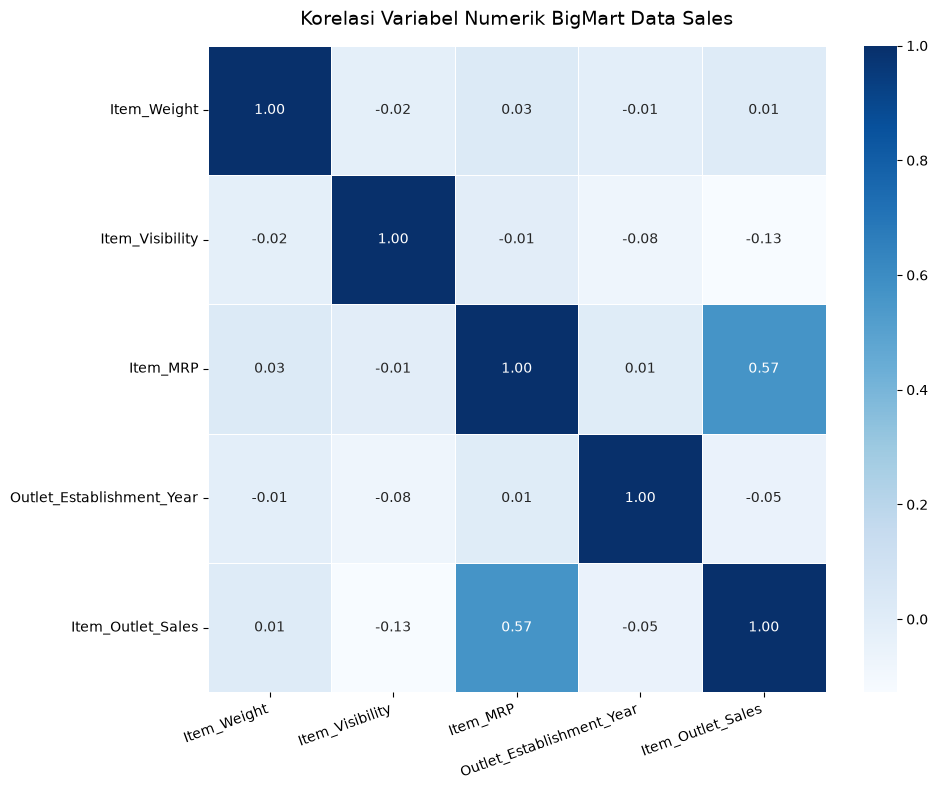

In [176]:
plt.figure(figsize=(10, 8))

df_numerik = df_clean.select_dtypes(include=['number']).corr()
sns.heatmap(
    df_numerik, 
    annot=True,        
    cmap='Blues',   
    fmt='.2f',         
    linewidths=0.5,    
    cbar=True          
)
plt.xticks(rotation=20,ha='right')
plt.yticks(rotation=0)  

plt.title('Korelasi Variabel Numerik BigMart Data Sales', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<b>Hasil pengamatan</b>
<p>
    kolom Item_MRP dengan kolom Item_Outlet_Sales memiliki korelasi paling kuat sebesar 0.57, maka arah analisa akan menuju kepada dua kolom ini
</p>

<h4>2. Ambil kolom yang dibutuhkan</h4>

In [203]:
#filter kolom yang dibutuhkan untuk analisa
kolom_cek = ['Item_Type', 'Item_MRP','Outlet_Type', 'Outlet_Location_Type','Outlet_Size','Item_Outlet_Sales']

df_analysis = df_clean[kolom_cek].copy()

''' Membulatkan nilai Item_Outlet_Sales menjadi 2 angka di belakang koma 
    Membulatkan nilai Item_MRP menjadi 2 angka di belakang koma 
'''
df_analysis['Item_Outlet_Sales'] = df_analysis['Item_Outlet_Sales'].round(2)
df_analysis['Item_MRP'] = df_analysis['Item_MRP'].round(2)

df_analysis.head()

,Item_Type,Item_MRP,Outlet_Type,Outlet_Location_Type,Outlet_Size,Item_Outlet_Sales
0,Dairy,249.81,Supermarket Type1,Tier 1,Medium,3735.14
1,Soft Drinks,48.27,Supermarket Type2,Tier 3,Medium,443.42
2,Meat,141.62,Supermarket Type1,Tier 1,Medium,2097.27
3,Fruits and Vegetables,182.10,Grocery Store,Tier 3,Small,732.38
4,Household,53.86,Supermarket Type1,Tier 3,High,994.71


<h4>3. Visualisasi data yang telah dipilih</h4>

<h5>a. Visualisasi harga retail dan Penjualan Berdasarkan Tipe Outlet</h5>

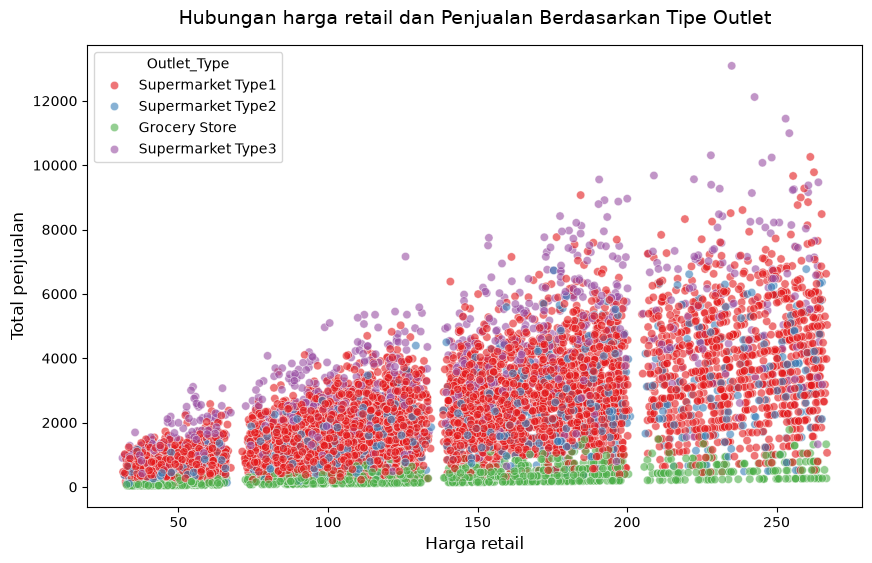

In [207]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analysis, 
    x='Item_MRP', 
    y='Item_Outlet_Sales', 
    hue='Outlet_Type',  # <-- Kolom pendukung utama untuk memecah insight
    alpha=0.6,
    palette='Set1'
)
plt.title('Hubungan harga retail dan Penjualan Berdasarkan Tipe Outlet', fontsize=14, pad=15)
plt.xlabel('Harga retail', fontsize=12)
plt.ylabel('Total penjualan', fontsize=12)
plt.show()

<b>Hasil pengamatan</b>
<p>
    Harga produk retail menentukan besar kecilnya potensi penjualan, namun Tipe Outlet adalah faktor penentu utama yang membedakan apakah sebuah produk bisa menghasilkan omzet tinggi atau tidak
</p>

<h5>b. Visualisasi Sebaran Penjualan Berdasarkan Masing-masing Tipe Outlet</h5>

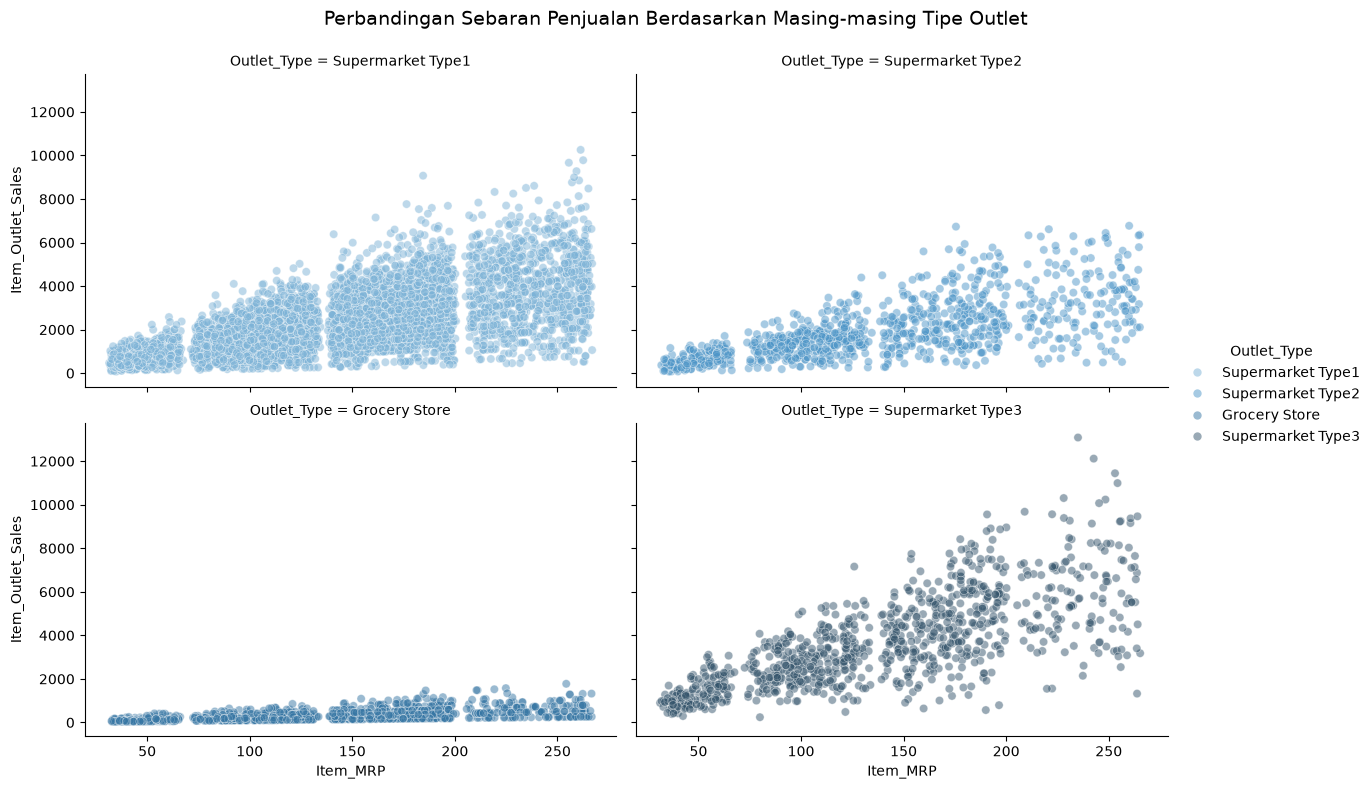

In [205]:
g = sns.relplot(
    data=df_clean,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    col='Outlet_Type',
    col_wrap=2, 
    hue='Outlet_Type',
    alpha=0.5,
    palette='Blues_d',
    height=4, 
    aspect=1.5
)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Perbandingan Sebaran Penjualan Berdasarkan Masing-masing Tipe Outlet', fontsize=14)


plt.show()

<b>Hasil pengamatan</b>
<p>
    Pemisahan panel ini membuktikan secara mutlak bahwa tipe outlet adalah pembeda performa yang sangat ekstrem. Jika sebelumnya pada grafik gabungan titik-titiknya tampak menumpuk, pemecahan ini memperjelas mengapa Supermarket Type 3 bisa menghasilkan penjualan belasan ribu, sementara Grocery Store hanya mampu mencetak angka di bawah 2.000.
</p>

<h5>c. Visualisasi Rata-rata omzet Berdasarkan Kategori Produk</h5>

C:\Users\User\AppData\Local\Temp\ipykernel_12408\3465140908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


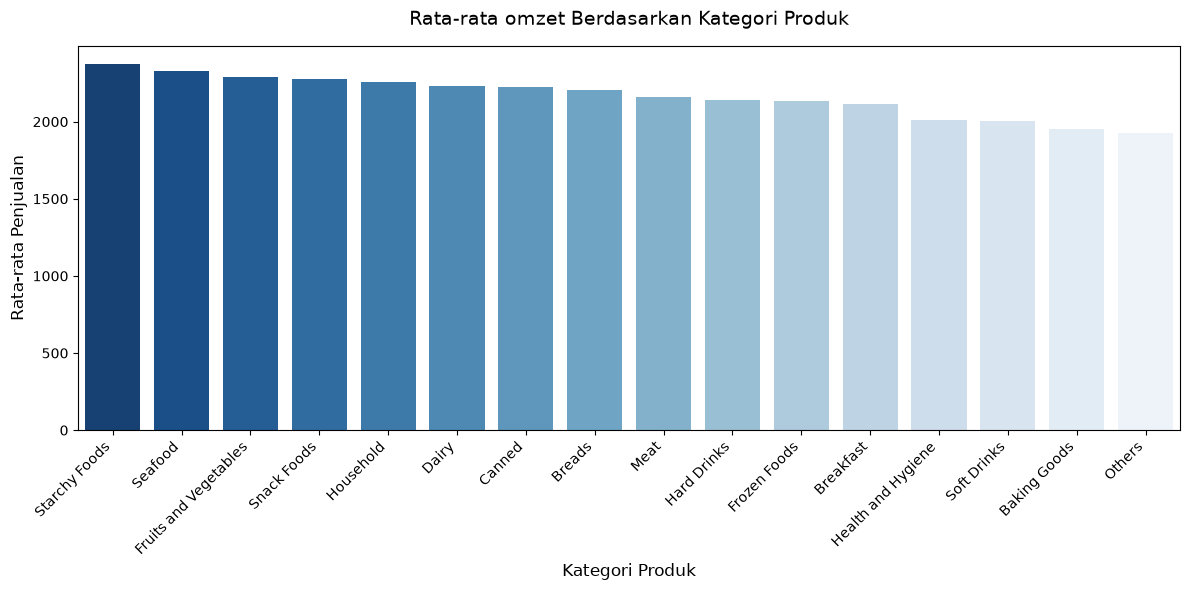

In [194]:
plt.figure(figsize=(12, 6))

item_order = df_clean.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values(ascending=False).index
sns.barplot(
    data=df_clean, 
    x='Item_Type', 
    y='Item_Outlet_Sales', 
    order=item_order,
    palette='Blues_r',
    errorbar=None
)

plt.title('Rata-rata omzet Berdasarkan Kategori Produk', fontsize=14, pad=15)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Rata-rata Penjualan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<b>Hasil Pengamatan</b>
<p>
    Secara keseluruhan rata-rata omzet setiap kategori cenderung stabil dan tidak menunjukkan perbedaan yang signifikan. Kategori Starchy  Foods, Seafood, Fruits and Vegetables, dan Snack Foods menduduki peringkat teratas dengan rata-rata omzet tertinggi
</p>

<h3>F. Hasil Analisis </h3> 


<b>Korelasi Positif antara Harga Produk dan Potensi Pendapatan Penjualan</b>
<p>
    Analisis awal menunjukkan adanya hubungan linier positif antara harga eceran produk (Item_MRP) dengan total pendapatan penjualan (Item_Outlet_Sales). Semakin tinggi harga suatu produk, semakin besar pula potensi batas maksimal omzet yang dapat dihasilkan oleh sistem penjualan.
</p>
<b>Tipe Outlet Merupakan Faktor Penentu Utama Variasi Omzet</b>
<p>
    Pengujian rata-rata omzet berdasarkan kategori produk memperlihatkan selisih nilai yang rapat di kisaran angka 1.900 hingga 2.400. Hal ini membuktikan bahwa jenis barang bukanlah faktor pemicu utama yang menciptakan perbedaan omzet secara drastis di antara toko.
</p>
<b>Kategori Produk (Item_Type) Memiliki Performa Penjualan yang Relatif Stabil dan Merata</b>
<p>
   Pengujian rata-rata omzet berdasarkan kategori produk memperlihatkan selisih nilai yang rapat di kisaran angka 1.900 hingga 2.400. Hal ini membuktikan bahwa jenis barang bukanlah faktor pemicu utama yang menciptakan perbedaan omzet secara drastis di antara toko.
</p>
<b>Rekomendasi Strategis dan Fokus Pengoptimalan Bisnis</b>
<p>
    Manajemen ritel disarankan untuk tidak membuang energi dalam merombak atau membatasi variasi stok kategori produk (Item_Type). Fokus strategi bisnis harus dialirkan penuh pada pengembangan format dan kapasitas gerai ke arah Supermarket, karena tipe outlet merupakan kunci utama yang terbukti paling efektif mendongkrak omzet perusahaan secara signifikan.
</p>
